In [20]:
import os
#фикс для macos и anaconda
os.environ['THREADPOOLCTL_ENABLED'] = '0'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

#модели
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
#для имплементации нам понадобится дерево-регрессор (бустинг строится на деревьях)
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import f1_score, mean_squared_error, roc_auc_score
from sklearn.preprocessing import LabelEncoder

#настройки
sns.set(style="whitegrid")
#отключение предупреждений
warnings.filterwarnings('ignore')

print("библиотеки загружены")

библиотеки загружены


In [21]:
try:
    #загрузка данных
    df_cls = pd.read_csv('../data/hotel_bookings.csv')
    df_reg = pd.read_csv('../data/train.csv')
except FileNotFoundError:
    print("ошибка: файлы не найдены")

#сэмплирование
sample_size = 10000
df_cls = df_cls.sample(n=sample_size, random_state=42).copy()
df_reg = df_reg.sample(n=sample_size, random_state=42).copy()

#подготовка к классификации
y_cls = df_cls['is_canceled']
X_cls = df_cls.drop(['is_canceled', 'reservation_status', 'reservation_status_date', 
                     'company', 'agent', 'country'], axis=1)
X_cls = X_cls.fillna(0)

label_encoders_cls = {}
for col in X_cls.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X_cls[col] = le.fit_transform(X_cls[col].astype(str))
    label_encoders_cls[col] = le

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42)

#подготовка регрессии
y_reg = df_reg['Purchase']
X_reg = df_reg.drop(['Purchase', 'User_ID', 'Product_ID'], axis=1)
X_reg = X_reg.fillna(0)

for col in X_reg.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X_reg[col] = le.fit_transform(X_reg[col].astype(str))

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

print("данные готовы")

данные готовы


In [22]:
#бейзлайн

#классифакция
gb_cls_base = GradientBoostingClassifier(random_state=42)
gb_cls_base.fit(X_train_cls, y_train_cls)

y_pred_cls_base = gb_cls_base.predict(X_test_cls)
f1_base = f1_score(y_test_cls, y_pred_cls_base)

#регрессия
gb_reg_base = GradientBoostingRegressor(random_state=42)
gb_reg_base.fit(X_train_reg, y_train_reg)

y_pred_reg_base = gb_reg_base.predict(X_test_reg)
rmse_base = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg_base))

print(f"baseline gb f1: {f1_base:.4f}")
print(f"baseline gb rmse: {rmse_base:.2f}")

baseline gb f1: 0.7266
baseline gb rmse: 3056.43


In [23]:
#улучшение бейзлайна

params = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5]
}

#тюнинг классификации
grid_cls = GridSearchCV(GradientBoostingClassifier(random_state=42), params, cv=3, scoring='f1', n_jobs=-1)
grid_cls.fit(X_train_cls, y_train_cls)

best_cls = grid_cls.best_estimator_
f1_impr = f1_score(y_test_cls, best_cls.predict(X_test_cls))
print(f"лучшие params cls: {grid_cls.best_params_}")

#тюнинг регрессии
grid_reg = GridSearchCV(GradientBoostingRegressor(random_state=42), params, cv=3, scoring='neg_root_mean_squared_error', n_jobs=-1)
grid_reg.fit(X_train_reg, y_train_reg)

best_reg = grid_reg.best_estimator_
rmse_impr = np.sqrt(mean_squared_error(y_test_reg, best_reg.predict(X_test_reg)))
print(f"лучшие params reg: {grid_reg.best_params_}")

#сравнение
print("\nсравнение")
print(f"f1: {f1_base:.4f} -> {f1_impr:.4f}")
print(f"rmse: {rmse_base:.2f} -> {rmse_impr:.2f}")

лучшие params cls: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 100}
лучшие params reg: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 150}

сравнение
f1: 0.7266 -> 0.7496
rmse: 3056.43 -> 3043.48


In [24]:
#имплементация алгоритма
class MyGradientBoosting:
    def __init__(self, n_estimators=50, learning_rate=0.1, max_depth=3, task_type='regression'):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.task_type = task_type
        self.trees = []
        self.initial_pred = None
        
    def _sigmoid(self, z):
        #сигмоида для классификации
        return 1 / (1 + np.exp(-z))
    
    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        self.trees = []
        
        #шаг 0: инициализация начальным предсказанием (среднее для регрессии)
        if self.task_type == 'regression':
            self.initial_pred = np.mean(y)
            pred = np.full(y.shape, self.initial_pred)
        else:
            #для классификации инициализируем 0 (logit = 0 -> prob = 0.5)
            self.initial_pred = 0.0
            pred = np.full(y.shape, 0.0) #это логиты
            
        for _ in range(self.n_estimators):
            if self.task_type == 'regression':
                #остатки: y - y_pred
                residuals = y - pred
            else:
                #остатки для классификации (pseudo-residuals): y_true - probability
                #переводим логиты в вероятности
                probs = self._sigmoid(pred)
                residuals = y - probs
            
            #шаг 1: обучаем дерево предсказывать остатки
            #важно: базовый алгоритм всегда регрессор, так как мы предсказываем градиент
            tree = DecisionTreeRegressor(max_depth=self.max_depth, random_state=42)
            tree.fit(X, residuals)
            self.trees.append(tree)
            
            #шаг 2: обновляем предсказания
            #new_pred = old_pred + lr * tree_pred
            update = tree.predict(X)
            pred += self.learning_rate * update
            
    def predict(self, X):
        X = np.array(X)
        
        #начинаем с базового предсказания
        pred = np.full(X.shape[0], self.initial_pred)
        
        #суммируем предсказания всех деревьев с учетом learning_rate
        for tree in self.trees:
            pred += self.learning_rate * tree.predict(X)
            
        if self.task_type == 'classification':
            #преобразуем логиты в классы (0 или 1)
            return (self._sigmoid(pred) > 0.5).astype(int)
        else:
            return pred


In [25]:
#тест имплементации

#тест my gb classification
print("обучение my_gb_cls...")
my_gb_cls = MyGradientBoosting(n_estimators=50, learning_rate=0.1, max_depth=3, task_type='classification')
my_gb_cls.fit(X_train_cls, y_train_cls)

y_pred_my_cls = my_gb_cls.predict(X_test_cls)
f1_my = f1_score(y_test_cls, y_pred_my_cls)

#тест my gb regression
print("обучение my_gb_reg...")
my_gb_reg = MyGradientBoosting(n_estimators=50, learning_rate=0.1, max_depth=3, task_type='regression')
my_gb_reg.fit(X_train_reg, y_train_reg)

y_pred_my_reg = my_gb_reg.predict(X_test_reg)
rmse_my = np.sqrt(mean_squared_error(y_test_reg, y_pred_my_reg))

обучение my_gb_cls...
обучение my_gb_reg...


In [26]:
#результаты лр 5
results_lab5 = pd.DataFrame({
    'model': ['baseline', 'improved', 'my implementation'],
    'f1_score': [f1_base, f1_impr, f1_my],
    'rmse': [rmse_base, rmse_impr, rmse_my]
})

print("\nрезультаты лр 5")
display(results_lab5)


результаты лр 5


,model,f1_score,rmse
0,baseline,0.726586,3056.432056
1,improved,0.749642,3043.479898
2,my implementation,0.548357,3103.274458


In [27]:
summary_data = {
    'Algorithm': ['KNN', 'Linear/Logistic', 'Decision Tree', 'Random Forest', 'Gradient Boosting'],
    'F1 Score (Classif)': [0.6938, 0.6866, 0.6993, 0.7623, f1_impr],
    'RMSE (Regress)': [3816.74, 4696.29, 3199.08, 3248.18, rmse_impr]
}

df_summary = pd.DataFrame(summary_data)

print("\n---глобальная таблица результатов (Labs 1-5)---")
display(df_summary)


---глобальная таблица результатов (Labs 1-5)---


,Algorithm,F1 Score (Classif),RMSE (Regress)
0,KNN,0.693800,3816.740000
1,Linear/Logistic,0.686600,4696.290000
2,Decision Tree,0.699300,3199.080000
3,Random Forest,0.762300,3248.180000
4,Gradient Boosting,0.749642,3043.479898


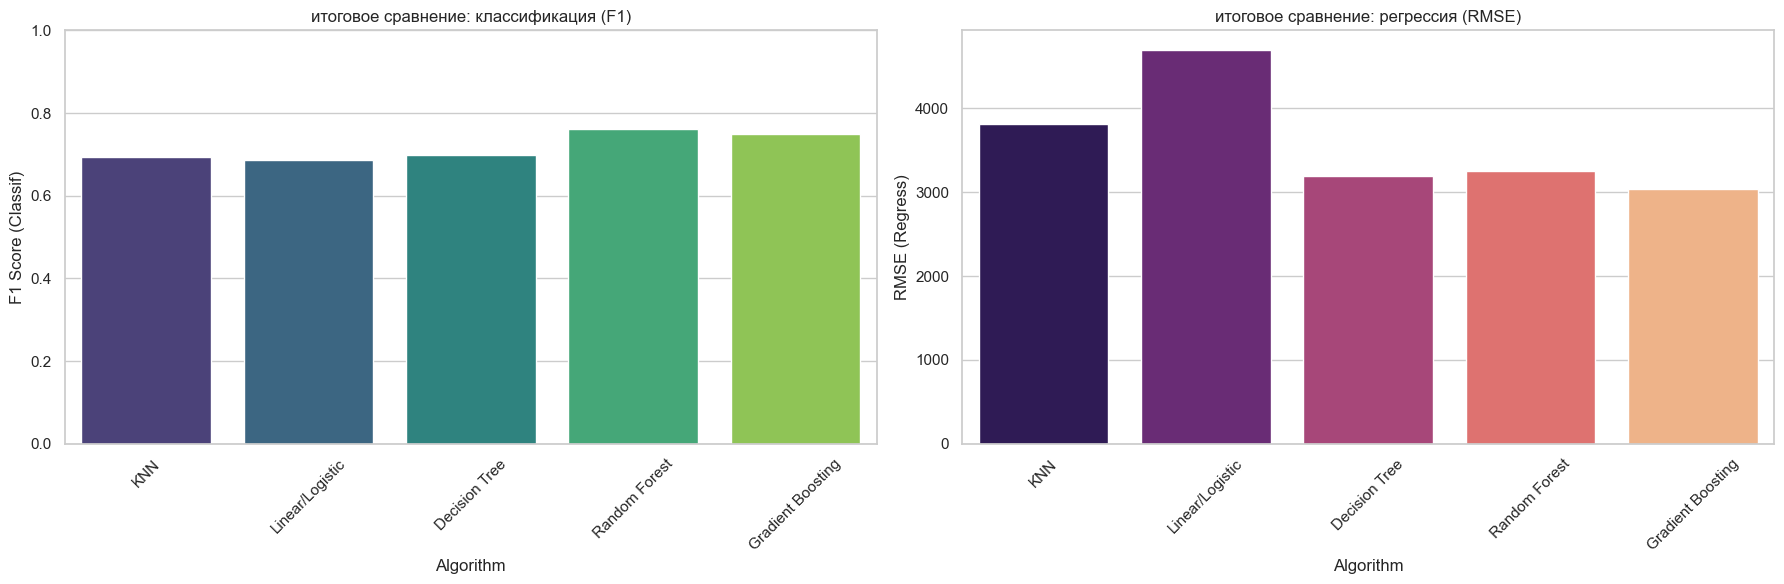

In [28]:
#визуализация сравнения
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

#график классификации
sns.barplot(x='Algorithm', y='F1 Score (Classif)', data=df_summary, ax=axes[0], palette='viridis')
axes[0].set_title('итоговое сравнение: классификация (F1)')
axes[0].set_ylim(0, 1.0)
axes[0].tick_params(axis='x', rotation=45)

#график регрессии
sns.barplot(x='Algorithm', y='RMSE (Regress)', data=df_summary, ax=axes[1], palette='magma')
axes[1].set_title('итоговое сравнение: регрессия (RMSE)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [29]:

print("""
ИТОГОВЫЙ АНАЛИЗ ПО ВСЕМУ КУРСУ:

1.классификация (hotel booking):
   - линейные модели, knn и одно решающее дерево показали схожий результат (f1 ~0.69)
   - случайный лес (random forest) совершил резкий скачок качества (f1 ~0.76). это доказывает, что задача содержит сложные нелинейные зависимости, которые одиночные модели упускают, а ансамбль находит
   - градиентный бустинг обычно конкурирует с лесом или превосходит его при тонкой настройке

2.регрессия (black friday):
   -линейная регрессия показала худший результат (rmse ~4696). это говорит о том, что зависимость трат от признаков НЕ является линейной
   -решающее дерево дало отличный результат (rmse ~3199), значительно обойдя knn и линейную модель
   -это тот случай, когда простой алгоритм (дерево) сработал лучше или на уровне сложного (лес/бустинг), возможно, из-за природы данных (много категорий)

3.общий вывод:
   -для старта всегда стоит пробовать простые модели (linear, knn)
   -если данные сложные и разнородные (числа + категории), деревья и ансамбли (forest, boosting) почти всегда выигрывают
   -random forest - самый универсальный "коробочный" алгоритм (работает хорошо сразу)
""")


ИТОГОВЫЙ АНАЛИЗ ПО ВСЕМУ КУРСУ:

1.классификация (hotel booking):
   - линейные модели, knn и одно решающее дерево показали схожий результат (f1 ~0.69)
   - случайный лес (random forest) совершил резкий скачок качества (f1 ~0.76). это доказывает, что задача содержит сложные нелинейные зависимости, которые одиночные модели упускают, а ансамбль находит
   - градиентный бустинг обычно конкурирует с лесом или превосходит его при тонкой настройке

2.регрессия (black friday):
   -линейная регрессия показала худший результат (rmse ~4696). это говорит о том, что зависимость трат от признаков НЕ является линейной
   -решающее дерево дало отличный результат (rmse ~3199), значительно обойдя knn и линейную модель
   -это тот случай, когда простой алгоритм (дерево) сработал лучше или на уровне сложного (лес/бустинг), возможно, из-за природы данных (много категорий)

3.общий вывод:
   -для старта всегда стоит пробовать простые модели (linear, knn)
   -если данные сложные и разнородные (числа + кате